In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import glob
# from upsetplot import from_contents, plot
from matplotlib import pyplot

from pathlib import Path

from dfmodel import DigitalFamilyBinary

from sklearn.metrics import class_likelihood_ratios, recall_score
from sklearn.preprocessing import MinMaxScaler

custom_params = {"axes.spines.right": False, "axes.spines.top": False}
sns.set_theme(context="paper", style="ticks", rc=custom_params, font="Arial", font_scale=1.5)



In [2]:
bootstrap_columns = [f"target_bootstrap_{n}" for n in range(1000)]

# 30-day Mortality

In [34]:
combined_results = pd.read_csv(
    "design_matrix_test_mortality_risk.tsv",
    sep="\t",
)

outcome_col = "Mortality 30 Day Prob"
label_col = "survival_30_day"
title = "30 Day Mortality"

In [35]:
mort_median = combined_results[outcome_col].mean()
mort_mad = combined_results[outcome_col].std()
mort_mad, mort_median

(0.09401526325702657, 0.06377088235294082)

In [36]:
recall_score(
    combined_results[label_col], np.where(combined_results[outcome_col] > 0.0, 1, 0)
)

0.7976190476190477

In [5]:
cutoffs = [
    max(mort_median - mort_mad, 0),
    mort_median,
    mort_median + mort_mad,
    mort_median + (mort_mad * 2),
    mort_median + (mort_mad * 3),
   # mort_median + (mort_mad * 4),
]
cutoffs

[0,
 0.06377088235294082,
 0.1577861456099674,
 0.251801408866994,
 0.3458166721240205]

In [6]:
bootstrapped_recalls = []
plr_gp = []
thresholds = []

subsample = combined_results.copy()

for col in bootstrap_columns:

    bootstrapped_recalls.append(
        recall_score(subsample[label_col], np.where(subsample[col] > 0.0, 1, 0))
    )

    for cutoff in cutoffs:

        plr_gp.append(
            class_likelihood_ratios(subsample[label_col], np.where(subsample[col] > cutoff, 1, 0))[0]
        )
        thresholds.append(cutoff)



mort_lr_df = pd.DataFrame(
    {
        "LR+": plr_gp,
        "Cutoff": thresholds,
        "Label": [title for _ in range(len(plr_gp))],
    }
)

mort_bs_df = pd.DataFrame(
    {
        "Recall": bootstrapped_recalls,
        "Label": [title for _ in range(len(bootstrapped_recalls))],
    }
)


# Deterioration

In [7]:
combined_results = pd.read_csv(
    "design_matrix_test_deterioration.tsv",
    sep="\t",
)

outcome_col = "Future Deterioration Mean"
label_col = "future_deterioration"
title = "Persistent Organ Dysfunction"

In [8]:
od_median = combined_results[outcome_col].mean()
od_mad = combined_results[outcome_col].std()
od_mad, od_median

(0.15658299174778556, 0.2600817647058823)

In [9]:
cutoffs = [
    0,
    od_median - od_mad,
    od_median,
    od_median + od_mad,
    od_median + (od_mad * 2),
    od_median + (od_mad * 3),
   # od_median + (od_mad * 4),
]
cutoffs

[0,
 0.10349877295809673,
 0.2600817647058823,
 0.41666475645366785,
 0.5732477482014534,
 0.729830739949239]

In [10]:
bootstrapped_recalls = []
plr_gp = []
thresholds = []

subsample = combined_results.copy()

for col in bootstrap_columns:

    bootstrapped_recalls.append(
        recall_score(subsample[label_col], np.where(subsample[col] > 0.0, 1, 0))
    )

    for cutoff in cutoffs:

        plr_gp.append(
            class_likelihood_ratios(subsample[label_col], np.where(subsample[col] > cutoff, 1, 0))[0]
        )
        thresholds.append(cutoff)



od_lr_df = pd.DataFrame(
    {
        "LR+": plr_gp,
        "Cutoff": thresholds,
        "Label": [title for _ in range(len(plr_gp))],
    }
)

od_bs_df = pd.DataFrame(
    {
        "Recall": bootstrapped_recalls,
        "AUC": bootstrapped_aucs,
        "Precision": bootstrapped_precisions,
        "Label": [title for _ in range(len(bootstrapped_recalls))],
    }
)


/Users/aaron/Documents/projects/sadt/notebooks/revisions/second_250806/DigitalFamilyAnalysis/.venv/lib/python3.12/site-packages/sklearn/utils/_param_validation.py:218: UndefinedMetricWarning: `positive_likelihood_ratio` is ill-defined and set to `np.nan`. Use the `replace_undefined_by` param to 
  return func(*args, **kwargs)
/Users/aaron/Documents/projects/sadt/notebooks/revisions/second_250806/DigitalFamilyAnalysis/.venv/lib/python3.12/site-packages/sklearn/utils/_param_validation.py:218: UndefinedMetricWarning: `positive_likelihood_ratio` is ill-defined and set to `np.nan`. Use the `replace_undefined_by` param to 
  return func(*args, **kwargs)
/Users/aaron/Documents/projects/sadt/notebooks/revisions/second_250806/DigitalFamilyAnalysis/.venv/lib/python3.12/site-packages/sklearn/utils/_param_validation.py:218: UndefinedMetricWarning: `positive_likelihood_ratio` is ill-defined and set to `np.nan`. Use the `replace_undefined_by` param to 
  return func(*args, **kwargs)
/Users/aaron/Doc

# ICU

In [11]:
combined_results = pd.read_csv(
    "design_matrix_test_infection_icu.tsv",
    sep="\t",
)

outcome_col = "ICU Prob"
label_col = "critical_care"
title = "ICU"

In [12]:
icu_median = combined_results[outcome_col].mean()
icu_mad = combined_results[outcome_col].std()
icu_mad, icu_median

(0.0913312803336922, 0.08605117647058777)

In [13]:
cutoffs = [
    max(icu_median - icu_mad, 0),
    icu_median,
    icu_median + icu_mad,
    icu_median + (icu_mad * 2),
    icu_median + (icu_mad * 3),
   # icu_median + (icu_mad * 4),
]
cutoffs

[0,
 0.08605117647058777,
 0.17738245680427997,
 0.2687137371379722,
 0.3600450174716644]

In [14]:
bootstrapped_recalls = []
plr_gp = []
thresholds = []

subsample = combined_results.copy()

for col in bootstrap_columns:


    bootstrapped_recalls.append(
        recall_score(subsample[label_col], np.where(subsample[col] > 0.0, 1, 0))
    )

    for cutoff in cutoffs:

        plr_gp.append(
            class_likelihood_ratios(subsample[label_col], np.where(subsample[col] > cutoff, 1, 0))[0]
        )
        thresholds.append(cutoff)



icu_lr_df = pd.DataFrame(
    {
        "LR+": plr_gp,
        "Cutoff": thresholds,
        "Label": [title for _ in range(len(plr_gp))],
    }
)

icu_bs_df = pd.DataFrame(
    {
        "Recall": bootstrapped_recalls,
        "AUC": bootstrapped_aucs,
        "Precision": bootstrapped_precisions,
        "Label": [title for _ in range(len(bootstrapped_recalls))],
    }
)


In [15]:
combined_bs_df = pd.concat(
    [mort_bs_df, od_bs_df, icu_bs_df]
)

combined_lr_df = pd.concat(
    [mort_lr_df, od_lr_df, icu_lr_df]
)

/var/folders/8l/w243_nbs0ks6hphych47fmd80000gn/T/ipykernel_80130/3332801044.py:49: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  axs[0].set_xticklabels(
/var/folders/8l/w243_nbs0ks6hphych47fmd80000gn/T/ipykernel_80130/3332801044.py:88: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  axs[1].set_xticklabels(
/var/folders/8l/w243_nbs0ks6hphych47fmd80000gn/T/ipykernel_80130/3332801044.py:126: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  axs[2].set_xticklabels(
/var/folders/8l/w243_nbs0ks6hphych47fmd80000gn/T/ipykernel_80130/3332801044.py:174: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  axs[3].set_xticklabels(


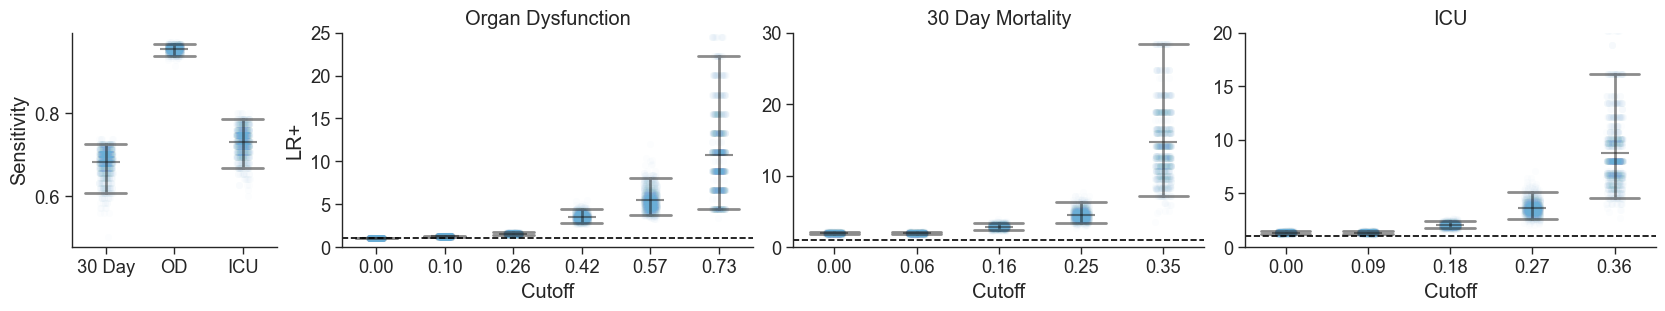

In [21]:
import matplotlib.pyplot as plt

fig, axs = plt.subplots(
    nrows=1,
    ncols=4,
    width_ratios=[0.5, 1, 1, 1],
    constrained_layout=True,
    #sharey="row",
)

axs = axs.ravel()

sns.pointplot(
    data=combined_bs_df,
    x="Label",
    y="Recall",
    hue="Label",
    palette='dark:k',
    errorbar=("pi", 95),
    marker="_",
    markersize=20,
    markerfacecolor="k",
    color="k",
    capsize=.6,
    err_kws={"color": "k", "linewidth": 2},
    linewidth=2,
    legend=False,
    ax=axs[0],
    alpha=0.5,
)

sns.stripplot(
    data=combined_bs_df,
    x="Label",
    y="Recall",
    #hue="Label",
    color="#6AAED6",
    ax=axs[0],
    #palette="Blues",
    linewidth=0,
    legend=False,
    alpha=0.02,
    zorder=1

)

axs[0].set_xlabel("")
axs[0].set_ylabel("Sensitivity")
axs[0].set_xticklabels(
    ["30 Day", "OD", "ICU"]
)

sns.pointplot(
    data=od_lr_df,
    x="Cutoff",
    y="LR+",
    hue="Cutoff",
    palette='dark:k',
    errorbar=("pi", 95),
    marker="_",
    markersize=20,
    markerfacecolor="k",
    color="k",
    capsize=.6,
    err_kws={"color": "k", "linewidth": 2},
    linewidth=2,
    legend=False,
    ax=axs[1],
    alpha=0.5
)

sns.stripplot(
    data=od_lr_df,
    x="Cutoff",
    y="LR+",
    ax=axs[1],
    color="#6AAED6",
    linewidth=0,
    legend=False,
    alpha=0.02,
    zorder=1,

)

axs[1].set_xlabel("Cutoff\nOrgan Dysfunction")

axs[1].axhline(y=1, linestyle='--', color='black')
axs[1].set_xticklabels(
    [f"{val:.2f}" for val in od_lr_df['Cutoff']],
)
axs[1].set_ylim(0, 60)

sns.pointplot(
    data=mort_lr_df,
    x="Cutoff",
    y="LR+",
    hue="Cutoff",
    palette='dark:k',
    errorbar=("pi", 95),
    marker="_",
    markersize=20,
    markerfacecolor="k",
    color="k",
    capsize=.6,
    err_kws={"color": "k", "linewidth": 2},
    linewidth=2,
    legend=False,
    ax=axs[2],
    alpha=0.5
)

sns.stripplot(
    data=mort_lr_df,
    x="Cutoff",
    y="LR+",
    ax=axs[2],
    color="#6AAED6",
    linewidth=0,
    legend=False,
    alpha=0.02,
    zorder=1,

)

axs[2].set_xlabel("Cutoff\n30 Day Mortality")
axs[2].set_xticklabels(
    [f"{val:.2f}" for val in mort_lr_df['Cutoff']],
)

axs[2].axhline(y=1, linestyle='--', color='black')

#axs[3].set_ylim(0, 60)


sns.pointplot(
    data=icu_lr_df,
    x="Cutoff",
    y="LR+",
    hue="Cutoff",
    palette='dark:k',
    errorbar=("pi", 95),
    marker="_",
    markersize=20,
    markerfacecolor="k",
    color="k",
    capsize=.6,
    err_kws={"color": "k", "linewidth": 2},
    linewidth=2,
    legend=False,
    ax=axs[3],
    alpha=0.5
)

sns.stripplot(
    data=icu_lr_df,
    x="Cutoff",
    y="LR+",
    ax=axs[3],
    color="#6AAED6",
    linewidth=0,
    legend=False,
    alpha=0.02,
    zorder=1

)

axs[1].set_xlabel("Cutoff")
axs[1].set_title("Organ Dysfunction")
axs[2].set_xlabel("Cutoff")
axs[2].set_title("30 Day Mortality")
axs[3].set_xlabel("Cutoff")
axs[3].set_title("ICU")

axs[3].set_xticklabels(
    [f"{val:.2f}" for val in icu_lr_df['Cutoff']],
)

axs[3].axhline(y=1, linestyle='--', color='black')

axs[1].set_ylim(0, 25)
axs[2].set_ylim(0, 30)
axs[2].set_ylabel("")
axs[3].set_ylim(0, 20)
axs[3].set_ylabel("")

fig.set_size_inches(
    (8.27 * 2, 3)
)

fig.savefig("3_clinical_data_df_metrics.pdf", bbox_inches="tight", dpi=300, transparent=True)


In [32]:
combined_bs_df[['Recall', 'Label']].groupby("Label").mean()

,Recall
Label,
30 Day Mortality,0.681345
ICU,0.730707
Persistent Organ Dysfunction,0.955085


In [37]:
combined_bs_df[['Recall', 'Label']].groupby("Label").max()

,Recall
Label,
30 Day Mortality,0.738095
ICU,0.800000
Persistent Organ Dysfunction,0.971564
